Transformación de Datos: Encoding y Escalamiento

**Curso:** Fundamentos de Aprendizaje Automático
**Tema:** Transformación de datos (Encoding + Escalamiento)

## Objetivos de esta notebook

1. Explorar un dataset real con columnas **numéricas y categóricas mezcladas**.
2. Decidir, columna por columna, **qué técnica de encoding** aplicar (Label, Ordinal, One-Hot) y por qué.
3. Aplicar **escalamiento** (`StandardScaler` vs `MinMaxScaler`) y entender cuándo usar cada uno.
4. Entender por qué el problema que vamos a resolver con este dataset **no es de regresión, sino de clasificación** — y qué viene en la próxima clase.
5. Practicar el mismo flujo completo con un dataset nuevo (Adult Census Income).

Usaremos el dataset **Penguins**, disponible directamente en `seaborn` , no necesita descarga manual ni autenticación, así que podemos enfocarnos 100% en el procesamiento de datos.

## 0. Setup y carga de datos

`seaborn` trae varios datasets de ejemplo listos para usar con `sns.load_dataset(...)`. `penguins` contiene mediciones físicas de 3 especies de pingüinos observados en 3 islas del archipiélago Palmer, en la Antártida.

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 1. Exploración inicial (EDA rápido)

Antes de transformar nada, necesitamos entender **qué tipo de dato es cada columna** y **qué tan "sucia"** está.

In [21]:
print("Dimensiones:", df.shape)
df.info()

Dimensiones: (344, 7)
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [22]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

**Observaciones iniciales:**
- Hay pocos valores nulos en total, y aparecen **en las mismas filas** (probablemente pingüinos que no se pudieron medir/sexar correctamente en campo).
- `sex` es la columna con más nulos (11) — y será justamente nuestra variable objetivo en este notebook.
- Las columnas numéricas (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) miden distintas características físicas del pingüino.
- `species` e `island` son categóricas.

In [23]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
df.describe(include='object')

C:\Users\yejaramilm\AppData\Local\Temp\ipykernel_31048\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,152,168,168


In [24]:
df['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [25]:
df['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

## 2. Definiendo el problema: predecir `sex`

En este notebook, la pregunta que queremos responder es:

> **A partir de las medidas físicas y la especie/isla de un pingüino, ¿podemos predecir si es macho o hembra?**

Antes de seguir, mira los valores posibles de `sex`:

In [26]:
df['sex'].unique()

<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

Solo dos valores: `Male` y `Female` (y algunos nulos). Ya con esto puedes anticipar algo importante , vuelve a este punto cuando lleguemos a la Sección 8.

## 3. Clasificando cada columna

Aquí está el paso mental más importante de esta notebook — para cada columna nos preguntamos:

> **¿Qué tipo de variable es? ¿Tiene orden natural? ¿Cuántas categorías tiene?**

| Columna | Tipo | ¿Qué hacemos? |
|---|---|---|
| `species` | Categórica , 3 categorías (Adelie, Chinstrap, Gentoo) | One-Hot Encoding — no hay orden entre especies |
| `island` | Categórica , 3 categorías (Torgersen, Biscoe, Dream) | One-Hot Encoding — no hay orden entre islas |
| `bill_length_mm` | Numérica continua | Escalar |
| `bill_depth_mm` | Numérica continua | Escalar |
| `flipper_length_mm` | Numérica continua | Escalar |
| `body_mass_g` | Numérica continua | Escalar |
| `sex` | **Target** — categórica, 2 categorías (Male/Female) | Es lo que queremos predecir |

Esta tabla es exactamente el ejercicio mental de la clase: **orden natural + número de categorías → técnica de encoding**. Fíjate que aquí **no hay ninguna variable ordinal**

## 4. Manejo de valores faltantes

Como vimos, los nulos aparecen en muy pocas filas (menos del 4% del dataset) y varias columnas están vacías en las mismas filas — probablemente registros incompletos de campo. Con un dataset tan pequeño y limpio en general, la estrategia más simple y razonable aquí es **eliminar esas filas** en vez de imputar.

> **Nota:** esto es una decisión de diseño, no una regla absoluta. Si tu dataset tuviera muchos más nulos, o si eliminarlos te hiciera perder una fracción importante de los datos, la imputación (como hicimos con `Age` en el Titanic) sería la mejor opción. Aquí, perder ~11 filas de 344 (~3%) es un costo aceptable a cambio de simplicidad.

In [27]:
filas_antes = df.shape[0]
df = df.dropna()
filas_despues = df.shape[0]

print(f"Filas antes: {filas_antes}")
print(f"Filas después: {filas_despues}")
print(f"Filas eliminadas: {filas_antes - filas_despues}")

df.isnull().sum()

Filas antes: 344
Filas después: 333
Filas eliminadas: 11


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

## 5. Encoding de variables categóricas

### 5.1 `species` e `island` — One-Hot Encoding

Ambas son nominales (sin orden) y tienen pocas categorías (3 cada una) — el caso ideal para One-Hot Encoding, tal como vimos en clase.

In [28]:
df_encoded = pd.get_dummies(df, columns=['species', 'island'], prefix=['species', 'island'], dtype=int)
df_encoded.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen
0,39.1,18.7,181.0,3750.0,Male,1,0,0,0,0,1
1,39.5,17.4,186.0,3800.0,Female,1,0,0,0,0,1
2,40.3,18.0,195.0,3250.0,Female,1,0,0,0,0,1
4,36.7,19.3,193.0,3450.0,Female,1,0,0,0,0,1
5,39.3,20.6,190.0,3650.0,Male,1,0,0,0,0,1


### 5.2 `sex` — nuestra variable objetivo

Como `sex` es lo que queremos predecir (no un feature de entrada), la codificamos por separado, de forma simple: `Male` = 0, `Female` = 1. Con exactamente 2 categorías, este mapeo no introduce ningún orden falso — no hay una tercera opción "entre" macho y hembra que pudiera malinterpretarse.

In [29]:
df_encoded['sex'] = df_encoded['sex'].map({'Male': 0, 'Female': 1})
df_encoded['sex'].value_counts()

sex
0    168
1    165
Name: count, dtype: int64

## 6. Separar train/test antes de escalar

Como vimos en clase: el escalamiento se **aprende (`.fit()`) solo con los datos de entrenamiento**, y se **aplica (`.transform()`)** tanto a train como a test — nunca al revés, para evitar *data leakage*.

In [30]:
X = df_encoded.drop(columns=['sex'])
y = df_encoded['sex']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
X_train.head()

Train: (266, 10) Test: (67, 10)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen
1,39.5,17.4,186.0,3800.0,1,0,0,0,0,1
250,47.3,15.3,222.0,5250.0,0,0,1,1,0,0
22,35.9,19.2,189.0,3800.0,1,0,0,1,0,0
341,50.4,15.7,222.0,5750.0,0,0,1,1,0,0
194,50.9,19.1,196.0,3550.0,0,1,0,0,1,0


## 7. Escalamiento: ¿StandardScaler o MinMaxScaler?

Antes de escalar, miremos las distribuciones de nuestras 4 variables numéricas continuas.

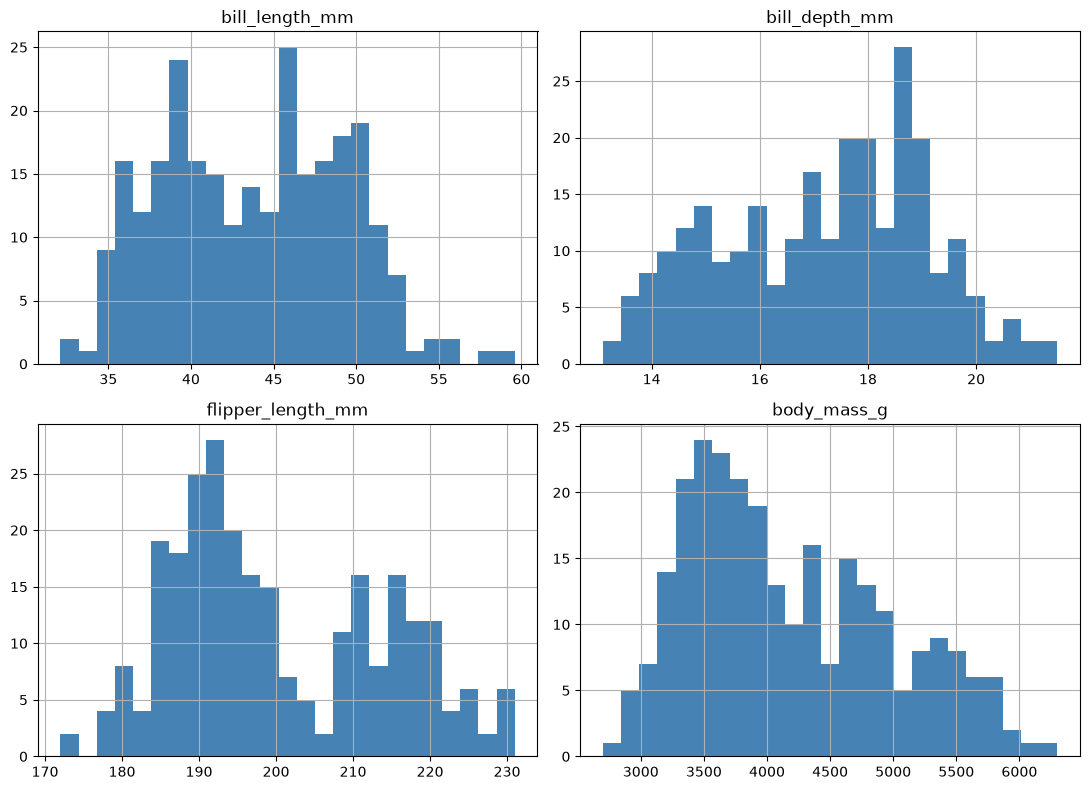

In [31]:
columnas_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), columnas_numericas):
    ax.hist(X_train[col], bins=25, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Lectura de las gráficas:**

Las 4 variables se ven razonablemente simétricas, sin outliers extremos evidentes — son medidas físicas directas (longitud de pico, profundidad de pico, longitud de aleta, masa corporal), y no tienen la cola larga .

**Decisión:** con distribuciones razonablemente normales y sin outliers marcados, **`StandardScaler`** es la opción por defecto más adecuada para las 4 columnas.

> **Para comparar:** si quisieras alimentar estos datos a una red neuronal con activación sigmoide, o si necesitaras un rango acotado y conocido, `MinMaxScaler` sería la alternativa — pero para el caso general (y para el modelo de clasificación que veremos la próxima clase), `StandardScaler` es la elección más segura aquí.

In [32]:
scaler = StandardScaler()

# Fit SOLO con train
scaler.fit(X_train[columnas_numericas])

# Transform en train y test (usando lo aprendido en train)
X_train[columnas_numericas] = scaler.transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

X_train.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen
1,-0.782824,0.112551,-1.039309,-0.471716,1,0,0,0,0,1
250,0.638674,-0.998246,1.590128,1.352251,0,0,1,1,0,0
22,-1.438901,1.064663,-0.820189,-0.471716,1,0,0,1,0,0
341,1.203629,-0.786665,1.590128,1.981205,0,0,1,1,0,0
194,1.294750,1.011768,-0.308909,-0.786193,0,1,0,0,1,0


In [33]:
# Verificamos: en train, las columnas numéricas deben tener media ~0 y std ~1
X_train[columnas_numericas].describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02
mean,-1.028417e-15,-2.671213e-16,8.581273e-16,-6.678033e-18
std,1.001885e+00,1.001885e+00,1.001885e+00,1.001885e+00
min,-2.131426e+00,-2.161937e+00,-2.061867e+00,-1.855414e+00
25%,-8.238293e-01,-7.866652e-01,-7.471489e-01,-7.861925e-01
50%,-8.290019e-03,1.654463e-01,-3.089094e-01,-2.830293e-01
75%,8.391418e-01,7.472922e-01,8.597293e-01,7.232971e-01
max,2.880268e+00,2.281250e+00,2.247488e+00,2.673055e+00


> **Pregunta para reflexionar:** ¿por qué en `X_test` la media de estas columnas después de escalar **no** va a dar exactamente 0? (Pista: recuerda de qué datos aprendió el `scaler` la media y la desviación estándar que usó para transformar test.)

In [34]:
X_test[columnas_numericas].describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,67.000000,67.000000,67.000000,67.000000
mean,0.178713,-0.058766,0.267779,0.200420
std,0.969660,1.193619,1.087760,1.047816
min,-1.785163,-2.109042,-1.769708,-1.666728
25%,-0.627918,-1.130483,-0.674109,-0.644678
50%,0.292412,-0.046134,0.202370,0.031448
75%,1.094283,0.905977,1.078849,0.911983
max,1.896154,2.122564,2.174448,2.295682


## 8. Dataset final, listo para modelar

Después de eliminar filas con nulos, codificar categóricas y escalar numéricas, este es nuestro dataset final:

In [35]:
print("Columnas finales de X:", list(X_train.columns))
print()
X_train.head()

Columnas finales de X: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species_Adelie', 'species_Chinstrap', 'species_Gentoo', 'island_Biscoe', 'island_Dream', 'island_Torgersen']



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen
1,-0.782824,0.112551,-1.039309,-0.471716,1,0,0,0,0,1
250,0.638674,-0.998246,1.590128,1.352251,0,0,1,1,0,0
22,-1.438901,1.064663,-0.820189,-0.471716,1,0,0,1,0,0
341,1.203629,-0.786665,1.590128,1.981205,0,0,1,1,0,0
194,1.294750,1.011768,-0.308909,-0.786193,0,1,0,0,1,0


---
## 9. ¿Por qué este NO es un problema de Regresión Lineal?

Volvamos a nuestra variable objetivo `y` (`sex`, ya codificada como 0/1):

In [36]:
y.value_counts()

sex
0    168
1    165
Name: count, dtype: int64

`sex` solo puede tomar **dos valores: 0 (Male) o 1 (Female)**. No es un número continuo como el precio de una casa o la progresión de una enfermedad — es una **categoría**.

### ¿Qué pasaría si de todas formas usáramos Regresión Lineal aquí?

Recordemos la fórmula de la regresión lineal:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$

Esta ecuación puede devolver **cualquier número real**: -3.7, 0.2, 1.5, 15.8... Pero nuestra variable objetivo solo tiene sentido como 0 o 1. Si el modelo predice `0.42`, ¿qué significa eso? ¿Es "un poco macho, un poco hembra"? Si predice `1.8` o `-0.3`, esos valores ni siquiera están dentro del rango válido de la variable.

Vamos a comprobarlo con un experimento rápido: entrenamos una regresión lineal (aunque sabemos que no es la herramienta correcta) y vemos qué predice.

In [37]:
from sklearn.linear_model import LinearRegression

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

y_pred_lineal = modelo_lineal.predict(X_test)

print("Algunas predicciones de la regresión lineal:")
print(np.round(y_pred_lineal[:15], 2))

Algunas predicciones de la regresión lineal:
[ 0.29  0.67  0.64  0.11  0.68  0.34  0.57  0.8   0.74 -0.11  0.01  1.
  0.14  0.51 -0.26]


In [38]:
print(f"Predicción mínima: {y_pred_lineal.min():.2f}")
print(f"Predicción máxima: {y_pred_lineal.max():.2f}")

Predicción mínima: -0.42
Predicción máxima: 1.32


Como puedes ver, el modelo predice números como `0.73`, `-0.08`, `1.15`... **valores fuera del rango [0, 1]**, y ninguno de ellos es literalmente `0` o `1`. La regresión lineal simplemente no fue diseñada para responder preguntas de tipo "¿macho o hembra?" — fue diseñada para predecir **cantidades continuas**.

### La diferencia clave: Regresión vs. Clasificación

| | **Regresión** | **Clasificación** |
|---|---|---|
| Variable objetivo (`y`) | Continua (precio, temperatura, progresión de enfermedad) | Categórica (macho/hembra, spam/no spam, especie A/B/C) |
| Ejemplo de esta clase | `target` en `load_diabetes` (Notebook 1) | `sex` en Penguins (este notebook) |
| Salida del modelo | Cualquier número real | Una clase (o una probabilidad entre 0 y 1 de pertenecer a una clase) |
| Algoritmo que usamos | Regresión Lineal | **Regresión Logística** (próxima clase) |

### ¿Qué viene en la próxima clase?

La **Regresión Logística** resuelve exactamente este problema: en vez de dejar que la salida del modelo sea cualquier número, le aplica una función (la función **sigmoide**) que **aplasta cualquier número real al rango [0, 1]** — convirtiendo la salida en algo que sí podemos interpretar como una **probabilidad** ("probabilidad de que este pingüino sea hembra"). A partir de esa probabilidad, se decide la clase final (por ejemplo, si la probabilidad es mayor a 0.5, se predice "hembra").

**Todo el trabajo de esta notebook no se pierde** — el dataset que acabamos de limpiar, codificar y escalar es exactamente el que usaremos la próxima clase para entrenar el modelo de regresión logística. El procesamiento de datos es independiente del algoritmo que se use después.

> **Nota extra:** `species` también hubiera sido un buen candidato de variable objetivo para practicar — pero con 3 categorías en vez de 2, es un problema de **clasificación multiclase**. La regresión logística que veremos primero resuelve el caso binario (2 clases); su extensión a múltiples clases (softmax regression) es un tema que se puede explorar más adelante en el curso.

---
## 10. Ejercicio de práctica — Adult Census Income

**Dataset:** [Adult Census Income](https://www.kaggle.com/datasets/uciml/adult-census-income)

Este dataset contiene información demográfica y laboral de personas, y la tarea (para más adelante, con regresión logística) es predecir si una persona gana **más o menos de $50,000 al año** (columna `income`, con valores `<=50K` o `>50K`).

**Ya puedes anticipar algo importante:** al igual que con `sex` en Penguins, `income` es una variable de **2 categorías** — este es, de nuevo, un problema de **clasificación**, no de regresión. Tu tarea en este ejercicio es únicamente el **procesamiento y la transformación de columnas** — el modelo lo entrenaremos en la próxima notebook.

### Instrucciones

**1. Descarga y carga el dataset**

Puedes descargarlo manualmente desde el link de arriba (botón "Download") y subirlo a tu entorno de trabajo, o usar `kagglehub` si ya tienes tus credenciales de Kaggle configuradas:
```python
import kagglehub
path = kagglehub.dataset_download('uciml/adult-census-income')
```

**2. Explora el dataset**
- ¿Cuántas filas y columnas tiene?
- ¿Qué columnas son numéricas y cuáles categóricas? (`df.info()`, `df.describe(include='object')`)
- ¿Hay valores nulos? **Cuidado:** en este dataset los nulos a veces no aparecen como `NaN`, sino como el string `"?"` — revisa los valores únicos de las columnas categóricas con `.unique()` para detectarlos, y conviértelos a `NaN` con `.replace('?', np.nan)` antes de decidir cómo manejarlos.

**3. Clasifica cada columna categórica** (haz una tabla como la de la Sección 3 de este notebook) y decide la técnica de encoding para cada una. Como guía, estas son las columnas categóricas que vas a encontrar — piensa en cada una:

| Columna | Pistas para decidir |
|---|---|
| `workclass` | ¿Tiene orden natural entre "Private", "Self-emp", "Government", etc.? |
| `education` | Ojo: el dataset también trae `education.num` — ¿qué relación tiene con `education`? ¿Cuál usarías? |
| `marital.status` | ¿Nominal o tiene algún orden? |
| `occupation` | ¿Cuántas categorías tiene? ¿Es alta o baja cardinalidad? |
| `relationship` | ¿Nominal? |
| `race` | ¿Nominal? |
| `sex` | ¿Cuántas categorías tiene? (pista: igual que `sex` en Penguins) |
| `native.country` | Esta es la más interesante: ¿cuántos países distintos hay? ¿Qué pasa si aplicas One-Hot directamente? Revisa la técnica de **Agrupación** que vimos en clase (agrupar categorías poco frecuentes en "Otros") antes de decidir tu encoding final. |

**4. Aplica el encoding** que decidiste para cada columna categórica.

**5. Revisa las variables numéricas** (`age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`):
- Grafica sus distribuciones con histogramas (como hicimos en la Sección 7).
- ¿Alguna tiene una distribución muy sesgada o con outliers extremos? (pista: revisa especialmente `capital.gain` y `capital.loss`).
- Decide, columna por columna, si usarías `StandardScaler`, `MinMaxScaler` o `RobustScaler`, y **justifica tu elección con una frase** para cada una.

**6. Haz el `train_test_split`, y aplica el escalamiento correctamente** (fit solo en train, transform en train y test).

**7. Pregunta final de reflexión:** después de todo el procesamiento, ¿cuántas columnas terminó teniendo tu `X` final, comparado con las columnas originales del dataset? ¿Por qué crecieron (o no) tanto las columnas? Relaciona tu respuesta con las técnicas de encoding que elegiste en el paso 3.

In [ ]:
# Ejercicio - Tu código aquí

# 1. Descargar y cargar el dataset
# import kagglehub
# path = kagglehub.dataset_download('uciml/adult-census-income')
# df_adult = pd.read_csv(...)

# 2. Explorar


# 3. Clasificar columnas categóricas (puedes hacerlo en una celda markdown o con prints)


# 4. Aplicar encoding


# 5. Revisar distribuciones numéricas y decidir escalamiento


# 6. Train/test split + escalamiento


# 7. Reflexión final (respóndela en una celda markdown)
